# COVID-19 Mortality Across Countries: An Exploratory Data Analysis

## Project Overview

The COVID-19 pandemic affected countries very differently, with substantial variation in infection rates, mortality rates, vaccination uptake, government responses, and healthcare resources. Understanding these differences may provide insight into factors associated with better or worse pandemic outcomes.

This project combines data from multiple sources, including:

- Our World in Data (OWID) COVID-19 statistics
- Oxford COVID Government Response Tracker Stringency Index
- World Bank demographic and healthcare indicators

The resulting dataset contains one record per country and includes measures of COVID-19 outcomes, vaccination coverage, government response, demographics, economic conditions, healthcare resources, and population density.

The primary outcome of interest is:

**Total COVID-19 deaths per million population**

The objective of this exploratory analysis is to investigate relationships between COVID-19 mortality and potential explanatory variables, identify patterns in the data, assess data quality, and generate hypotheses for subsequent modeling and prediction.


## Load Libraries and Data

The final analytical dataset created during the data wrangling phase will be used throughout this exploratory analysis.

The dataset contains country-level COVID-19 outcomes, vaccination coverage, government response measures, demographic characteristics, healthcare indicators, and economic variables. The following libraries will be used for data manipulation, visualization, and statistical exploration.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

pd.set_option("display.max_columns", None)

In [3]:
covid = pd.read_csv(
    "../data/processed/covid_analysis_dataset.csv"
)

covid.shape

(239, 22)

## Initial Data Inspection

Before exploring relationships among variables, it is important to verify that the dataset loaded correctly and to understand its structure, dimensions, and variable types.

In [4]:
covid.head()

,country,code,continent,population,total_cases,total_cases_per_million,total_deaths,total_deaths_per_million,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,stringency_index,median_age,gdp_per_capita,hospital_beds_per_thousand,life_expectancy,diabetes_prevalence,iso_code,country_wb,population_density,health_expenditure_per_capita,health_expenditure_pct_gdp
0,Afghanistan,AFG,Asia,40578847.0,235214.0,5796.4683,7998.0,197.09776,47.195450,45.270844,6.727495,27.394580,16.752001,1983.812622,0.35,65.616997,11.7,AFG,Afghanistan,61.328691,81.521126,21.508444
1,Albania,ALB,Europe,2827614.0,337234.0,119264.5100,3608.0,1275.98740,47.717087,45.244260,14.230054,41.782108,35.943001,21641.074219,2.90,78.768799,10.6,ALB,Albania,90.867226,465.570435,7.357504
2,Algeria,DZA,Africa,45477391.0,272440.0,5990.6690,6881.0,151.30595,17.239624,14.251447,1.265796,48.367728,27.983000,15501.919922,1.61,76.128899,17.5,DZA,Algeria,18.793445,208.939117,5.021889
3,American Samoa,ASM,Oceania,48365.0,8359.0,172831.6000,34.0,702.98770,NaN,NaN,NaN,NaN,27.927000,NaN,NaN,72.752098,NaN,ASM,American Samoa,246.125000,NaN,NaN
4,Andorra,AND,Europe,79722.0,48015.0,602280.4400,159.0,1994.43070,72.643684,67.109460,54.026493,33.486770,42.832001,65928.304688,NaN,84.016403,10.1,AND,Andorra,166.731915,3668.447510,8.646717


In [5]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              239 non-null    object 
 1   code                                 239 non-null    object 
 2   continent                            239 non-null    object 
 3   population                           237 non-null    float64
 4   total_cases                          233 non-null    float64
 5   total_cases_per_million              233 non-null    float64
 6   total_deaths                         233 non-null    float64
 7   total_deaths_per_million             233 non-null    float64
 8   people_vaccinated_per_hundred        217 non-null    float64
 9   people_fully_vaccinated_per_hundred  215 non-null    float64
 10  total_boosters_per_hundred           208 non-null    float64
 11  stringency_index                

In [6]:
covid.describe().T

,count,mean,std,min,25%,50%,75%,max
population,237.0,3.384130e+07,1.364037e+08,513.000000,397542.000000,5.456796e+06,2.250904e+07,1.425423e+09
total_cases,233.0,3.344073e+06,1.146156e+07,0.000000,25292.000000,1.914960e+05,1.279115e+06,1.034368e+08
total_cases_per_million,233.0,2.083471e+05,2.059958e+05,0.000000,20186.773000,1.355382e+05,3.510781e+05,7.698068e+05
total_deaths,233.0,3.054047e+04,1.096326e+05,0.000000,172.000000,1.937000e+03,1.412200e+04,1.238189e+06
total_deaths_per_million,233.0,1.276360e+03,1.338187e+03,0.000000,141.097660,8.893516e+02,2.023351e+03,6.603977e+03
people_vaccinated_per_hundred,217.0,6.261500e+01,2.414233e+01,0.277072,44.640140,6.808708e+01,8.047407e+01,1.120751e+02
people_fully_vaccinated_per_hundred,215.0,5.710050e+01,2.443564e+01,0.272658,39.363430,6.244032e+01,7.592957e+01,1.101884e+02
total_boosters_per_hundred,208.0,3.445340e+01,3.111692e+01,0.000000,7.718700,2.841672e+01,5.628939e+01,1.405325e+02
stringency_index,185.0,4.267543e+01,9.638693e+00,11.333896,36.689361,4.327304e+01,4.919622e+01,7.331321e+01
median_age,237.0,3.120876e+01,9.735554e+00,14.298000,22.243999,3.169800e+01,3.908000e+01,5.987500e+01


## Distribution of COVID-19 Mortality

The primary outcome of interest in this project is total COVID-19 deaths per million population. Before examining relationships with other variables, it is useful to understand the distribution of mortality across countries.

Summary statistics and visualizations will be used to identify the range, central tendency, variability, and potential outliers in the mortality data.

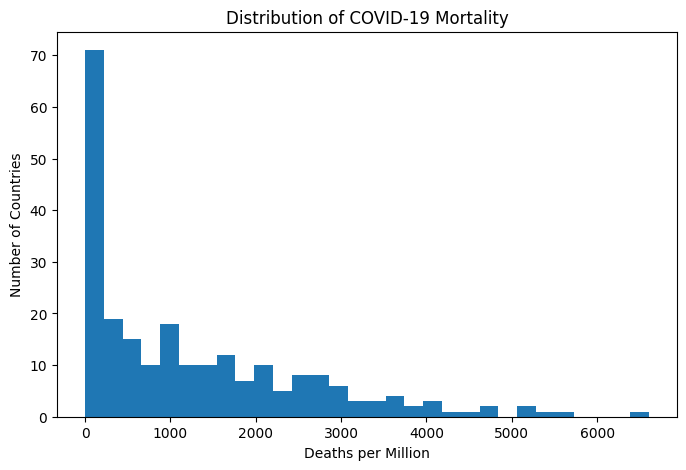

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    covid["total_deaths_per_million"].dropna(),
    bins=30
)

plt.xlabel("Deaths per Million")
plt.ylabel("Number of Countries")
plt.title("Distribution of COVID-19 Mortality")

plt.show()